# Data Visualization

In [152]:
# Load Data

import pandas as pd

car_ownership = pd.read_csv("../data/new_car.csv")
overall = pd.read_csv("../data/df_final.csv")
insurance = pd.read_csv("../data/new_insurance.csv")
oil_price = pd.read_csv("../data/new_oil.csv")
income = pd.read_csv("../data/new_income.csv")
interest = pd.read_csv("../data/new_interest.csv")

In [197]:
# Define Color Palette
colors = ['#A42A04', '#0047AB', '#301934', '#722F37']

## Plot 1: Median Income

In [207]:
import altair as alt

# Define first plot
area1 = alt.Chart(overall).mark_area(color = '#0047AB', opacity=0.5).encode(
    x=alt.X('year', title = 'Year', axis=alt.Axis(format='.0f', titleFontSize=14)),
    y=alt.Y('median_income', title='U.S. Dollars ($)', axis=alt.Axis(labelFontSize = 11, titleFontSize=14)),
    tooltip=[alt.Tooltip('year', title = 'Year'),
             alt.Tooltip('median_income:Q', title = 'Median Income ($)')]
).properties(title = alt.TitleParams(text = 'Real Median Family Income In The U.S. (1960-2024)', fontSize=16), height = 300, width = 600)

line1 = alt.Chart(overall).mark_line(color = '#0047AB').encode(
    x=alt.X('year', title = 'Year', axis=alt.Axis(format='.0f')),
    y=alt.Y('median_income', title='U.S. Dollars ($)'),
    tooltip=[alt.Tooltip('year', title = 'Year'),
             alt.Tooltip('median_income:Q', title = 'Median Income ($)')]
).properties(title='Real Median Family Income In The U.S. (1960-2024)')

chart1 = area1 + line1

bar2 = (
    alt.Chart(income)
    .mark_bar(color = '#301934')
    .encode(
        x=alt.X("year:N", title = "Year", axis=alt.Axis(labelFontSize = 9, titleFontSize=14)),
        y=alt.Y("difference:Q", title = "U.S. Dollars ($)", axis=alt.Axis(labelFontSize = 11, titleFontSize=14)),
        tooltip=[alt.Tooltip('year', title = 'Year'), alt.Tooltip('difference', title = 'Income Difference ($)')]
    )
    .properties(title = alt.TitleParams(text = 'Real Median Family Income Difference In The U.S. (1960-2024)', fontSize=16), height = 300, width = 600)
)


In [208]:
chart1.save('../website/plots/plot1.html')

In [209]:
bar2.save('../website/plots/plot1.5.html')

## Plot 2: Car Ownership

In [198]:
# Create selection criteria
select_car = alt.selection_point(
    fields=["cars"],
    bind=alt.binding_select(options=list(car_ownership["cars"].unique()),name="Select Vehicle Number "),
    value="0 vehicles")

# Create Chart Base
base = (
    alt.Chart(car_ownership)
    .mark_bar()
    .encode(
        x=alt.X("year:N", title = "Year", axis=alt.Axis(labelFontSize = 12, titleFontSize=14)),
        y=alt.Y("ownership_perc:Q", scale=alt.Scale(domain = [0,75]), title = "Percent of Households with Vehicles (%)", axis=alt.Axis(labelFontSize = 12, titleFontSize=14)),
        color=alt.Color("cars:N", scale=alt.Scale(domain = ['0 vehicles', '1 vehicle', '2 vehicles', '3 or more vehicles'], range = colors), 
                        title = "Vehicles", legend = alt.Legend(labelFontSize=12, titleFontSize=12)),
        tooltip=[alt.Tooltip('ownership_perc', title = "Percent (%)")]
    )
    .add_params(select_car)
    .transform_filter(select_car)
    .properties(title = alt.TitleParams(text = 'Household Vehicle Ownership (1960-2023)', fontSize=16), width = 500)
)

# Add trend line
trend_line = (
    alt.Chart(car_ownership)
    .mark_line(color='#71797E', strokeWidth=3, strokeDash=[5, 3])
    .encode(
        x=alt.X("year:N", title="Year"),
        y=alt.Y("ownership_perc:Q")
    )
    .add_params(select_car)
    .transform_filter(select_car)
    .transform_regression("year", "ownership_perc")
)

chart = base + trend_line

In [199]:
chart.save('../website/plots/plot2.html')

In [217]:
line1 = alt.Chart(interest).mark_line(color = '#722F37', strokeWidth=3, point=alt.OverlayMarkDef(color='#722F37', filled=True, size=80)).encode(
    x=alt.X('year', axis=alt.Axis(labels=False, ticks = False, title=None)),
    y=alt.Y('vehicle:Q', title='Percent of Households with 0 Vehicles (%)',axis=alt.Axis(labelFontSize = 12, titleFontSize=12)),
    tooltip=[alt.Tooltip('year', title = 'Year'),
             alt.Tooltip('vehicle:Q', title = 'Percent (%)')]
).properties(title=alt.TitleParams(text='Household Vehicle Ownership (0 Vehicles)', fontSize=16), height = 300, width = 525)

line2 = alt.Chart(interest).mark_line(color = '#722F37', strokeWidth=3, point=alt.OverlayMarkDef(color='#722F37', filled=True, size=80)).encode(
    x=alt.X('year', title = 'Year', axis=alt.Axis(format='.0f', titleFontSize=14)),
    y=alt.Y('Value:Q', title='U.S. Dollars (Millions)',axis=alt.Axis(labelFontSize = 12, titleFontSize=12)),
    tooltip=[alt.Tooltip('year', title = 'Year'),
             alt.Tooltip('Value:Q', title = 'U.S. Dollars (Millions)')]
).properties(title=alt.TitleParams(text='Total U.S. Motor Vehicle Loans (Inflation Adjusted)', fontSize=16), height = 300, width = 525)

final_line=line1 & line2

final_line

alt.VConcatChart(...)

In [218]:
final_line.save('../website/plots/plot2.5.html')

## Plot 3: Motor Insurance

In [91]:
overall_melted = overall.melt(id_vars='year', 
                    value_vars=['insurance', 'avg_cpi'],
                    var_name='metric', 
                    value_name='value')

overall_melted['metric'] = overall_melted['metric'].replace({
    'insurance': 'Motor Insurance',
    'avg_cpi': 'Avg CPI'
})

In [146]:
# Create Bar Chart Base
bar_chart = alt.Chart(overall_melted).mark_bar().encode(
    x=alt.X('year:N', title = 'Year', axis=alt.Axis(labelFontSize=11, titleFontSize=14)),
    y=alt.Y('value:Q', title='Price Inflation (%)', axis=alt.Axis(labelFontSize=12, titleFontSize=14)),
    color=alt.Color('metric:N',
                    scale=alt.Scale(domain=['Motor Insurance', 'Avg CPI'], range=['#A42A04', '#0047AB']),
                    legend=alt.Legend(title='Price Metric')),
    xOffset='metric:N',
    tooltip=[alt.Tooltip('metric', title = 'Metric'), alt.Tooltip('value', title = "Price Inflation (%)")]
).properties(
    title=alt.TitleParams(
        text='Motor Vehicle vs Average Annual Price Inflation (1960-2024)',
        fontSize=16),
        width=600,
        height=300)

In [147]:
bar_chart.save('../website/plots/plot3.html')

## Plot 4: Oil Prices

In [201]:
# Create Selection Criteria
selection = alt.selection_point(name='bar_select', fields=['year'], value=[{'year': 1990}])

# Create Bar Chart Base
bar_chart = alt.Chart(overall).mark_bar(color = '#722F37').encode(
    x=alt.X('year:N', title = 'Year', axis=alt.Axis(labelFontSize=12, titleFontSize=14)),
    y=alt.Y('oil_price:Q', title='Dollars Per Barrel ($)', axis=alt.Axis(labelFontSize=12, titleFontSize=14)),
    opacity=alt.condition(selection, alt.value(1.0), alt.value(0.2)),
    tooltip=[alt.Tooltip('year', title = 'Year'), alt.Tooltip('oil_price', title = "Price ($)")]
).properties(
    title=alt.TitleParams(
        text='Inflation Adjusted Crude Oil Price (1960-2024)',
        fontSize=16),
        width=660,
        height=300
).add_params(selection)

# Create Line Chart
base1 = alt.Chart(oil_price).mark_line(opacity=0).encode(
    x=alt.X('month:N', sort=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], title='Month', axis=alt.Axis(labelFontSize=12, titleFontSize=14)),
    y=alt.Y('Value:Q', title='Dollars Per Barrel ($)', axis=alt.Axis(labelFontSize=12, titleFontSize=14))
).properties(
    title=alt.TitleParams(text='Monthly Inflation Adjusted Crude Oil Price', fontSize=16),
    width=660,
    height=200
)

line_chart1 = alt.Chart(oil_price).mark_line(color = '#722F37').encode(
    x=alt.X('month:N', sort=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], title='Month', axis=alt.Axis(labelFontSize=12, titleFontSize=14)),
    y=alt.Y('Value:Q', title='Dollars Per Barrel ($)', axis=alt.Axis(labelFontSize=12, titleFontSize=14)),
    tooltip=[
        alt.Tooltip('month:N', title='Month'),
        alt.Tooltip('Value:Q', title='Price ($)')]
).transform_filter(selection).properties(
        width=660,
        height=200
    )

bottom_chart = base1 + line_chart1

whole_chart = bar_chart & bottom_chart

In [202]:
whole_chart.save('../website/plots/plot4.html')

## Plot 5: All Together!

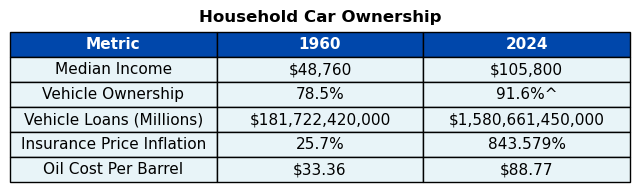

In [211]:
import matplotlib.pyplot as plt

# Create First Table
table_data = [['Median Income', '$48,760', '$105,800'],
              ['Vehicle Ownership', '78.5%', '91.6%^'],
              ['Vehicle Loans (Millions)', '$181,722,420,000', '$1,580,661,450,000'],
              ['Insurance Price Inflation', '25.7%', '843.579%'],
              ['Oil Cost Per Barrel', '$33.36', '$88.77']]

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off')

# Create Table Base
table = ax.table(
    cellText=table_data,
    colLabels=['Metric', '1960', '2024'],
    cellLoc='center',
    loc='center'
)
ax.set_title("Household Car Ownership", fontweight='bold')

# Set Table Thresholds
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)

# Set Header Color
for col in range(3):
    table[0, col].set_facecolor('#0047AB')
    table[0, col].set_text_props(color='white', fontweight='bold')

# Set Row Color
for row in range(1,6):
    table[row, 0].set_facecolor('#E8F4F8')
    table[row, 1].set_facecolor('#E8F4F8')
    table[row, 2].set_facecolor('#E8F4F8')

table

plt.savefig('../website/plots/table1.png', dpi=150, bbox_inches='tight', transparent=True)